# Baseline — Classification binaire (tumeur vs non-tumeur)

Objectif : démarrer un pipeline **propre** en important la classe `BrainMRIDataset` depuis le code du projet (`src/`).

> Dataset Kaggle : *Brain Tumor Classification (MRI)* — classes regroupées en **0 = no_tumor**, **1 = tumor**.


## 1) Imports & configuration

Ce notebook ajoute `./src` au `PYTHONPATH` pour pouvoir importer le package local **sans** devoir installer le projet en mode package.

> Si vous préférez une approche “projet installé”, faites : `poetry install` (sans `--no-root`).


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Added to sys.path:", SRC_DIR)


Project root: /home/alouiyaz/projects/PINKCC/PINKCC_challenge_Cité_neutral_Minds/notebooks
Added to sys.path: /home/alouiyaz/projects/PINKCC/PINKCC_challenge_Cité_neutral_Minds/notebooks/src


In [2]:
from collections import Counter
import random

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

sys.path.append(str(SRC_DIR))

print("SRC path ajouté :", SRC_DIR)
#  Import depuis le fichier Python du projet
from pinkcc_ct_seg.data.dataset import BrainMRIDataset

print("torch:", torch.__version__)


SRC path ajouté : /home/alouiyaz/projects/PINKCC/PINKCC_challenge_Cité_neutral_Minds/src
torch: 2.10.0+cu128


## 2) Chemins & transformations

On standardise la taille (ici **224×224**) pour pouvoir tester rapidement des modèles CNN (et éventuellement un ResNet plus tard).


In [3]:
from pathlib import Path

TRAIN_DIR = Path("data/raw/brain_mri/Training")
TEST_DIR  = Path("data/raw/brain_mri/Testing")

assert TRAIN_DIR.exists(), f"Dossier introuvable: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Dossier introuvable: {TEST_DIR}"

IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


## 3) Chargement du dataset via `BrainMRIDataset`

On instancie les datasets *train* et *test* en réutilisant la même classe du projet.


In [4]:
train_ds = BrainMRIDataset(TRAIN_DIR, transform=train_tfms)
test_ds  = BrainMRIDataset(TEST_DIR, transform=test_tfms)

print("Train samples:", len(train_ds))
print("Test samples :", len(test_ds))


Train samples: 2870
Test samples : 394


In [5]:
x, y = train_ds[0]
print("x shape:", tuple(x.shape), "| y:", y, "(0=no_tumor, 1=tumor)")


x shape: (3, 224, 224) | y: 0 (0=no_tumor, 1=tumor)


## 4) Distribution des classes (déséquilibre)


In [6]:
def class_distribution(ds: BrainMRIDataset):
    labels = [label for _, label in ds.samples]
    return Counter(labels)

print("Train distribution:", class_distribution(train_ds))
print("Test distribution :", class_distribution(test_ds))


Train distribution: Counter({1: 2475, 0: 395})
Test distribution : Counter({1: 289, 0: 105})


## 5) Visualisation : quelques images (avec labels)

Comme la classe **0** est minoritaire, un échantillon aléatoire donne souvent plus d’images “tumeur”.


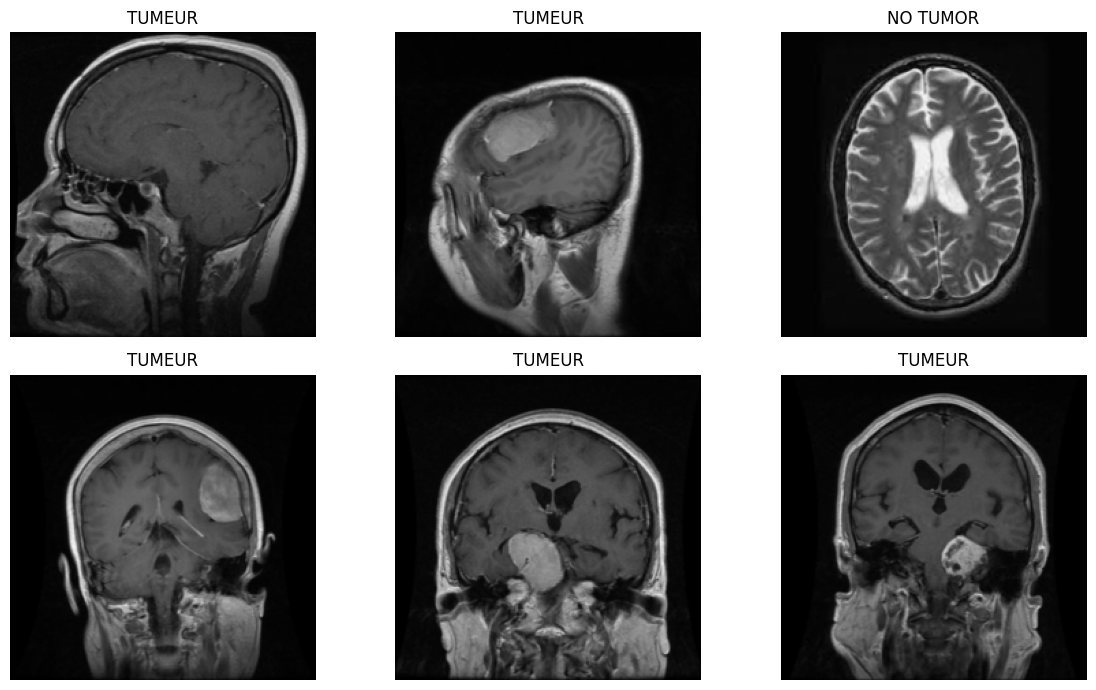

In [7]:
def show_samples(ds, n=6, seed=None):
    if seed is not None:
        random.seed(seed)
    idxs = random.sample(range(len(ds)), n)
    plt.figure(figsize=(12, 7))
    for i, idx in enumerate(idxs, start=1):
        x, y = ds[idx]
        # dé-normaliser pour l'affichage
        x_disp = x.clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        x_disp = (x_disp * std) + mean
        x_disp = x_disp.permute(1, 2, 0).clamp(0, 1).numpy()

        plt.subplot(2, 3, i)
        plt.imshow(x_disp)
        plt.axis('off')
        plt.title("TUMEUR" if y == 1 else "NO TUMOR")
    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=6, seed=42)


## 6) DataLoaders (prêt pour l’entraînement)

La suite logique : split *train/val* + modèle baseline + métriques.


In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("Batch x:", xb.shape, "Batch y:", yb.shape)


Batch x: torch.Size([32, 3, 224, 224]) Batch y: torch.Size([32])


In [9]:
for x, y in train_loader:
    print(y.dtype, y.min().item(), y.max().item())
    break

torch.int64 0 1
